In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver # for saving the states after each run

c:\ML-DL\AgenticAI-LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
load_dotenv()

from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="google/gemma-4-26b-a4b-it:free"
)

In [16]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [17]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [18]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [19]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

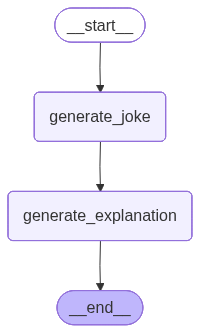

In [20]:
workflow

In [21]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go to therapy?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his **upper crust** personality!',
 'explanation': 'This joke is a play on words (a pun) that relies on double meanings. To understand why it is funny, you have to look at the two different ways the words are used:\n\n**1. The "Crust" Pun**\n*   **The Pizza Meaning:** The "crust" is the outer layer of the dough in a pizza.\n*   **The Figurative Meaning:** This is a play on the word **"trust."** When someone says they have "trust issues," it means they find it hard to rely on or believe in others. By swapping "trust" for "crust," the joke connects the pizza maker\'s job to his emotional problems.\n\n**2. The "Upper Crust" Pun**\n*   **The Pizza Meaning:** In baking, the "upper crust" would literally be the top part of the pizza.\n*   **The Figurative Meaning:** "Upper crust" is an English idiom used to describe **high-society, weal

In [22]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to therapy?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his **upper crust** personality!', 'explanation': 'This joke is a play on words (a pun) that relies on double meanings. To understand why it is funny, you have to look at the two different ways the words are used:\n\n**1. The "Crust" Pun**\n*   **The Pizza Meaning:** The "crust" is the outer layer of the dough in a pizza.\n*   **The Figurative Meaning:** This is a play on the word **"trust."** When someone says they have "trust issues," it means they find it hard to rely on or believe in others. By swapping "trust" for "crust," the joke connects the pizza maker\'s job to his emotional problems.\n\n**2. The "Upper Crust" Pun**\n*   **The Pizza Meaning:** In baking, the "upper crust" would literally be the top part of the pizza.\n*   **The Figurative Meaning:** "Upper crust" is an English idiom used to describe *

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to therapy?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his **upper crust** personality!', 'explanation': 'This joke is a play on words (a pun) that relies on double meanings. To understand why it is funny, you have to look at the two different ways the words are used:\n\n**1. The "Crust" Pun**\n*   **The Pizza Meaning:** The "crust" is the outer layer of the dough in a pizza.\n*   **The Figurative Meaning:** This is a play on the word **"trust."** When someone says they have "trust issues," it means they find it hard to rely on or believe in others. By swapping "trust" for "crust," the joke connects the pizza maker\'s job to his emotional problems.\n\n**2. The "Upper Crust" Pun**\n*   **The Pizza Meaning:** In baking, the "upper crust" would literally be the top part of the pizza.\n*   **The Figurative Meaning:** "Upper crust" is an English idiom used to describe 

### Time Travel

In [24]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f17328f-ddb8-607b-8000-261c35aee5f3"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f17328f-ddb8-607b-8000-261c35aee5f3'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-28T19:38:52.010303+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17328f-ddb3-6274-bfff-24564b350b49'}}, tasks=(PregelTask(id='9751b0e2-36a9-c998-7518-5ca31cc17024', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza maker go to therapy?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his **upper crust** personality!'}),), interrupts=())

In [26]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f17328f-ddb8-607b-8000-261c35aee5f3"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go to the therapist?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his toppings!',
 'explanation': 'This joke is a **pun**, which means it relies on words that sound like other words to create a double meaning. The humor comes from using pizza-related terms to describe emotional problems.\n\nHere is the breakdown of why it is funny:\n\n**1. The "Crust" Pun**\n*   **The Pizza meaning:** The "crust" is the outer layer of the dough.\n*   **The Therapy meaning:** The word sounds like **"trust."** In therapy, people often talk about "trust issues" (having difficulty trusting others). The joke replaces "trust issues" with "crust issues."\n\n**2. The "Toppings" Pun**\n*   **The Pizza meaning:** "Toppings" are the ingredients (pepperoni, mushrooms, etc.) placed on top of a pizza.\n*   **The Emotional meaning:** The joke uses the idea of being "used." In a relationship context, if someone is "using 

In [27]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to the therapist?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his toppings!', 'explanation': 'This joke is a **pun**, which means it relies on words that sound like other words to create a double meaning. The humor comes from using pizza-related terms to describe emotional problems.\n\nHere is the breakdown of why it is funny:\n\n**1. The "Crust" Pun**\n*   **The Pizza meaning:** The "crust" is the outer layer of the dough.\n*   **The Therapy meaning:** The word sounds like **"trust."** In therapy, people often talk about "trust issues" (having difficulty trusting others). The joke replaces "trust issues" with "crust issues."\n\n**2. The "Toppings" Pun**\n*   **The Pizza meaning:** "Toppings" are the ingredients (pepperoni, mushrooms, etc.) placed on top of a pizza.\n*   **The Emotional meaning:** The joke uses the idea of being "used." In a relationship context, i

### Updating State

In [28]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f17328f-ddb8-607b-8000-261c35aee5f3", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f173298-70a9-6500-8001-03097c0b0f4c'}}

In [29]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f173298-70a9-6500-8001-03097c0b0f4c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-28T19:42:42.166707+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17328f-ddb8-607b-8000-261c35aee5f3'}}, tasks=(PregelTask(id='f98de377-ee6b-cbf5-d218-835dbab8e1e6', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to the therapist?\n\nBecause he had too many **crust** issues and felt like everyone was just using him for his toppings!', 'explanation': 'This joke is a **pun**, which means it relies on words that sound like other words to create a double meaning. The humor comes from using pizza-related terms to de

In [30]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f173298-70a9-6500-8001-03097c0b0f4c"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little **crusty** and had too many **fillings**!',
 'explanation': 'This joke is a **pun**, which means it relies on words that have two different meanings to create humor. The joke works by using "medical" terms that also describe the physical characteristics of a samosa.\n\nHere is the breakdown of the two puns:\n\n**1. "Feeling a little crusty"**\n*   **The Samosa meaning:** A samosa is a fried pastry, so its outer shell is literally "crusty" or crunchy.\n*   **The Human meaning:** In slang, if a person is feeling "crusty," it means they feel dirty, unwell, or generally unpleasant.\n\n**2. "Had too many fillings"**\n*   **The Samosa meaning:** The "filling" is the delicious mixture of potatoes, peas, or meat inside the pastry.\n*   *The Human meaning:** In a medical context, "fillings" refers to the material used by a dentist to repair a tooth. If a person has "too many fillings," it means

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little **crusty** and had too many **fillings**!', 'explanation': 'This joke is a **pun**, which means it relies on words that have two different meanings to create humor. The joke works by using "medical" terms that also describe the physical characteristics of a samosa.\n\nHere is the breakdown of the two puns:\n\n**1. "Feeling a little crusty"**\n*   **The Samosa meaning:** A samosa is a fried pastry, so its outer shell is literally "crusty" or crunchy.\n*   **The Human meaning:** In slang, if a person is feeling "crusty," it means they feel dirty, unwell, or generally unpleasant.\n\n**2. "Had too many fillings"**\n*   **The Samosa meaning:** The "filling" is the delicious mixture of potatoes, peas, or meat inside the pastry.\n*   *The Human meaning:** In a medical context, "fillings" refers to the material used by a dentist to repair a tooth. If a person has "too many